In [1]:
#| include: false

# /// script
# requires-python = ">=3.10"
# dependencies = [
#   "matplotlib",
#   "numpy",
#   "pandas",
#   "pymc",
#   "scipy",
#   "seaborn",
# ]
# ///


In [2]:
%matplotlib inline
import numpy as np
import scipy as sp
import matplotlib as mpl
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import pandas as pd
pd.set_option('display.width', 500)
pd.set_option('display.max_columns', 100)
pd.set_option('display.notebook_repr_html', True)
import seaborn as sns
sns.set_style("whitegrid")
sns.set_context("poster")
import pymc as pm
import arviz as az

## Monks working on manuscripts

From McElreath:

>Now imagine that the monks take breaks on some days. On those days, no manuscripts are completed. Instead, the wine cellar is opened and more earthly delights are practiced. As the monastery owner, you'd like to know how often the monks drink. The obstacle for inference is that there will be zeros on honest non-drinking days, as well, just by chance. So how can you estimate the number of days spent drinking?

![St. Bernardus Prior 8 — a Belgian abbey beer whose name is a happy coincidence for Bayesians.](assets/a-st-bernardus-prior-8.jpg)

The kind of model used to solve this problem is called a **Mixture Model**. We'll see these in more detail next week, but here is a simple version that arises in Poisson regression.

Let $p$ be the probability that the monks spend the day drinking, and $\lambda$ be the mean number of manuscripts completed, when they work.


### Likelihood

The likelihood of observing 0 manuscripts produced is is:

 $$\cal{L}(y=0) = p + (1-p) e^{-\lambda},$$

since the Poisson likelihood of $y$ is $ \lambda^y exp(–\lambda)/y!$

Likelihood of a non-zero $y$ is:

 $$\cal{L}(y \ne 0) = (1-p) \frac{\lambda^y e^{-\lambda}}{y!}$$

This model can be described by this diagram, taken from Mc-Elreath

![Diagram of the zero-inflated Poisson process: monks either drink (producing zero manuscripts) or work (producing a Poisson-distributed count). From McElreath.](assets/zinfmonks.png)


### Generating the data

We're throwing bernoullis for whether a given day in the year is a drinking day or not...

In [3]:
from scipy.stats import binom
p_drink=0.2
rate_work=1
N=365
drink=binom.rvs(n=1, p=p_drink, size=N)
drink

array([0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0,
       1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1,
       0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0,
       0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0,
       0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0,

On days we dont drink, we produce some work...though it might be 0 work...

In [4]:
from scipy.stats import poisson
y = ( 1 - drink)*poisson.rvs(mu=rate_work, size=N)
y

array([0, 3, 0, 1, 1, 0, 0, 3, 2, 0, 1, 0, 4, 1, 2, 1, 3, 0, 0, 2, 2, 1,
       4, 0, 3, 0, 1, 2, 0, 1, 0, 0, 0, 0, 1, 1, 0, 2, 2, 0, 0, 1, 0, 0,
       0, 1, 2, 0, 2, 2, 0, 2, 0, 0, 0, 3, 0, 1, 2, 0, 3, 2, 0, 0, 0, 2,
       0, 0, 4, 0, 4, 1, 1, 2, 0, 0, 0, 1, 1, 0, 0, 0, 0, 2, 5, 0, 1, 0,
       0, 0, 0, 0, 0, 2, 2, 2, 0, 0, 0, 1, 1, 0, 0, 0, 2, 0, 1, 1, 0, 0,
       0, 0, 2, 3, 0, 2, 0, 0, 2, 1, 0, 1, 2, 0, 0, 0, 2, 1, 1, 0, 0, 1,
       0, 1, 2, 2, 1, 3, 0, 3, 0, 1, 2, 0, 0, 0, 0, 1, 0, 0, 4, 0, 0, 0,
       2, 1, 1, 0, 0, 0, 1, 0, 0, 2, 0, 0, 1, 0, 1, 1, 2, 0, 1, 0, 0, 0,
       1, 1, 1, 1, 1, 0, 0, 2, 1, 1, 2, 2, 1, 0, 2, 2, 2, 1, 0, 1, 0, 0,
       2, 0, 0, 0, 4, 1, 0, 0, 0, 0, 0, 0, 2, 2, 0, 1, 0, 2, 0, 1, 1, 0,
       1, 0, 1, 1, 0, 0, 3, 1, 2, 0, 4, 1, 0, 0, 0, 0, 2, 0, 0, 1, 5, 0,
       0, 0, 0, 0, 2, 1, 0, 0, 1, 0, 0, 2, 0, 0, 2, 1, 1, 1, 1, 0, 1, 0,
       0, 2, 0, 0, 1, 1, 2, 0, 1, 1, 2, 3, 0, 0, 0, 0, 2, 1, 0, 2, 0, 3,
       0, 0, 0, 4, 1, 0, 0, 0, 0, 0, 1, 2, 1, 0, 1,

Lets manufacture a histogram of manuscripts produced in a day.

In [5]:
zeros_drink=np.sum(drink)
a=drink==0
b=y==0
zeros_work=np.sum(a & b)
zeros_drink, zeros_work, np.sum(b)

(np.int64(76), np.int64(108), np.int64(184))

(array([184.,  97.,  60.,  13.,   8.,   3.,   0.,   0.,   0.]),
 array([0., 1., 2., 3., 4., 5., 6., 7., 8., 9.]),
 <BarContainer object of 9 artists>)

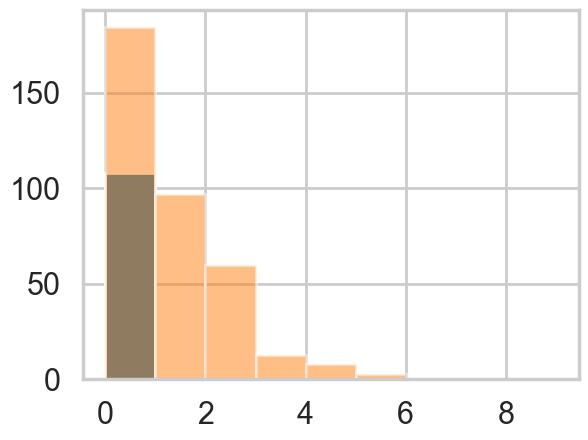

In [6]:
plt.hist(zeros_work*[0], bins=np.arange(10))
plt.hist(y, bins=np.arange(10), alpha=0.5)

### Lets throw in some domain expertise

*A survey of Abbey Heads has told us, that the most a monk could produce, ever, was 10 manuscripts in a day.*

## First model: just do a simple poisson

In [7]:
# theano import removed - not needed in modern pymc

In [8]:
def model_poisson(observed=None):
    with pm.Model() as model:
        lam=pm.HalfNormal("lambda", sigma=100)
        like = pm.Poisson("obsv", mu=lam, observed=observed)
    return model

In [9]:
model0 = model_poisson(observed=y)

In [10]:
with model0:
    trace0=pm.sample(3000)

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [lambda]


/Users/rahul/Library/Caches/uv/archive-v0/WJgPh5nRFVZl0DU9tt8M7/lib/python3.14/site-packages/rich/live.py:260: 
UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 3_000 draw iterations (4_000 + 12_000 draws total) took 1 seconds.


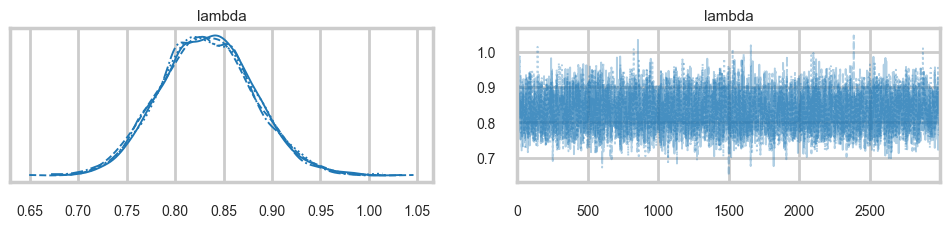

In [11]:
az.plot_trace(trace0);

In [12]:
az.summary(trace0)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
lambda,0.833,0.048,0.744,0.921,0.001,0.0,5480.0,8589.0,1.0


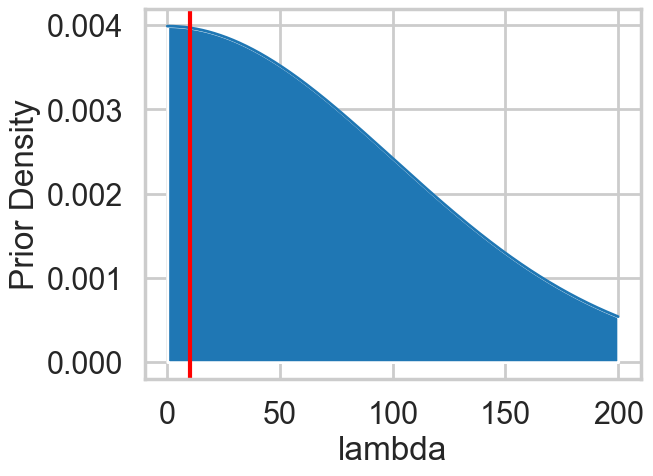

In [13]:
from scipy import stats
lbda  = np.linspace(0, 200, num=1000)
normpdf = stats.norm(loc=0,scale=100).pdf(lbda)
plt.plot(lbda, normpdf, lw=2)
plt.xlabel("lambda"); 
plt.ylabel("Prior Density");
plt.fill_between(lbda,0.,normpdf)
plt.axvline(10, 0 ,1, c="r", lw=3);

### Some proper workflow

Notice the prior specification though: at the 3$\sigma$ level, $\lambda$ could range from 0 to 300, ie from 0 to an extremely large number to an extremely large "mean" of counts. Not possible. Indeed, the max count is around 10. For a poisson, since the variance is equal to the mean, this means that (at 3$\sigma):

$$max(\lambda + 3\sqrt{\lambda}) < 10$$

Any prior should only take us marginally outside this range:

In [14]:
4+3*np.sqrt(4)

np.float64(10.0)

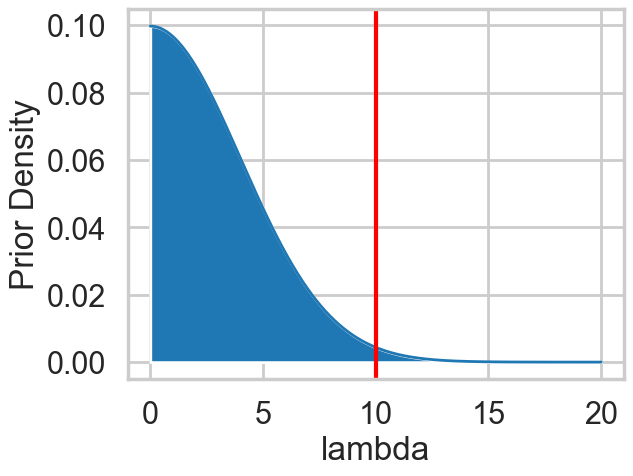

In [15]:
from scipy import stats
lbda  = np.linspace(0, 20, num=1000)
normpdf = stats.norm(loc=0,scale=4).pdf(lbda)
plt.plot(lbda, normpdf, lw=2)
plt.xlabel("lambda"); 
plt.ylabel("Prior Density");
plt.fill_between(lbda,0.,normpdf)
plt.axvline(10, 0 ,1, c="r", lw=3);

(array([377., 250., 177.,  91.,  56.,  26.,  14.,   5.,   0.,   4.]),
 array([ 0. ,  1.9,  3.8,  5.7,  7.6,  9.5, 11.4, 13.3, 15.2, 17.1, 19. ]),
 <BarContainer object of 10 artists>)

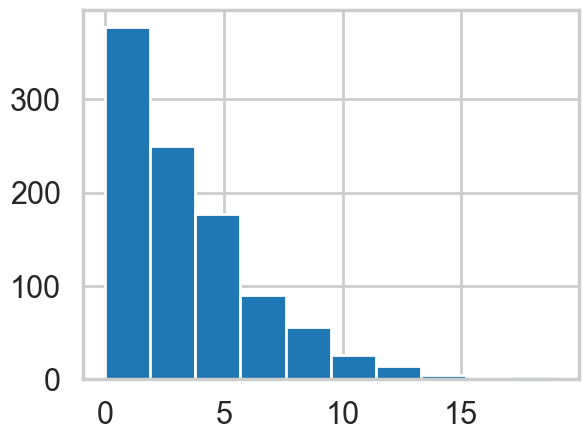

In [16]:
pois = stats.poisson.rvs(stats.halfnorm(scale=4).rvs(1000))
plt.hist(pois)

In [17]:
np.mean(pois > 10)

np.float64(0.032)

### Limiting the prior

Thus a prior should mainly limit $\lambda$ to values upto 4. To so this consider:

In [18]:
from scipy.stats import halfnorm
halfnorm.ppf(0.99, loc=0,scale=4)

np.float64(10.303317214195602)

In [19]:
def model_poisson1(sd, datasize, observed=None):
    with pm.Model() as model:
        lam=pm.HalfNormal("lambda", sigma=sd)
        like = pm.Poisson("obsv", mu=lam, shape = datasize, observed=observed)
    return model

### Simulating the Bayesian Joint distribution

This should be way enough!, So lets go again:


In [20]:
N = y.shape[0]
N

365

In [21]:
model1_pr = model_poisson1(4, N, observed=None)

In [22]:
with model1_pr:
    trace1_pr = pm.sample_prior_predictive(500)

Sampling: [lambda, obsv]


In [23]:
trace1_pr.prior['lambda'].shape, trace1_pr.prior['obsv'].shape

((1, 500), (1, 500, 365))

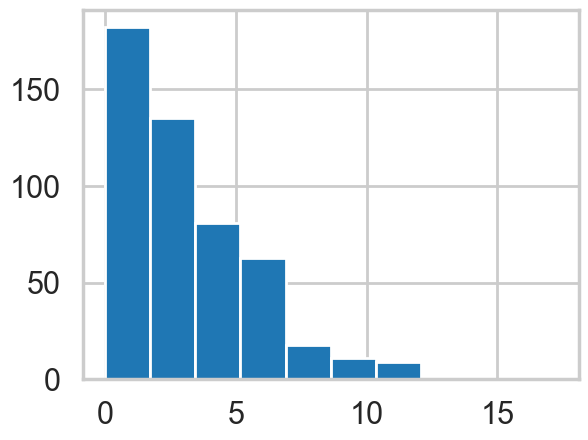

In [24]:
plt.hist(trace1_pr.prior['lambda'].values.flatten());

In [25]:
simy = trace1_pr.prior['obsv'].values.reshape(-1, N)

In [26]:
simu_lbdas = trace1_pr.prior['lambda'].values.flatten()
simu_lbdas.shape, simy.shape

((500,), (500, 365))

In [27]:
simu_lbdas = stats.halfnorm(scale=4).rvs(500)
simy = np.zeros((500, y.shape[0]))
for i in range(500):
    simy[i,:] = stats.poisson(simu_lbdas[i]).rvs(y.shape[0])

In [28]:
x_max = 21
bins = np.arange(0,x_max)
hists = np.apply_along_axis(lambda a: np.histogram(a, bins=bins)[0], 1, simy)

In [29]:
hists.shape #500 rows with 20 cols

(500, 20)

In [30]:
np.linspace(10,90,num=9, dtype=int)

array([10, 20, 30, 40, 50, 60, 70, 80, 90])

In [31]:
prctiles = np.percentile(hists,np.linspace(10,90,num=9, dtype=int),axis=0)

In [32]:
bin_interp = np.linspace(0,x_max-1,num=(x_max-1)*10)
bin_interp

array([ 0.        ,  0.10050251,  0.20100503,  0.30150754,  0.40201005,
        0.50251256,  0.60301508,  0.70351759,  0.8040201 ,  0.90452261,
        1.00502513,  1.10552764,  1.20603015,  1.30653266,  1.40703518,
        1.50753769,  1.6080402 ,  1.70854271,  1.80904523,  1.90954774,
        2.01005025,  2.11055276,  2.21105528,  2.31155779,  2.4120603 ,
        2.51256281,  2.61306533,  2.71356784,  2.81407035,  2.91457286,
        3.01507538,  3.11557789,  3.2160804 ,  3.31658291,  3.41708543,
        3.51758794,  3.61809045,  3.71859296,  3.81909548,  3.91959799,
        4.0201005 ,  4.12060302,  4.22110553,  4.32160804,  4.42211055,
        4.52261307,  4.62311558,  4.72361809,  4.8241206 ,  4.92462312,
        5.02512563,  5.12562814,  5.22613065,  5.32663317,  5.42713568,
        5.52763819,  5.6281407 ,  5.72864322,  5.82914573,  5.92964824,
        6.03015075,  6.13065327,  6.23115578,  6.33165829,  6.4321608 ,
        6.53266332,  6.63316583,  6.73366834,  6.83417085,  6.93

In [33]:
prctiles_interp = np.repeat(prctiles, 10,axis=1)

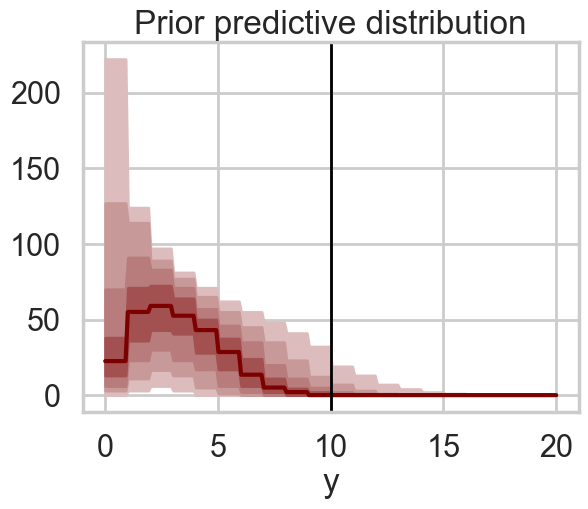

In [34]:
c_light ="#DCBCBC"
c_light_highlight ="#C79999"
c_mid ="#B97C7C"
c_mid_highlight ="#A25050"
c_dark ="#8F2727"
c_dark_highlight ="#7C0000"
for i,color in enumerate([c_light,c_light_highlight,c_mid,c_mid_highlight]):
    plt.fill_between(bin_interp,prctiles_interp[i,:],prctiles_interp[-1-i,:],alpha=1.0,color=color);


plt.plot(bin_interp,prctiles_interp[4,:],color=c_dark_highlight);
plt.axvline(x=10,ls='-',lw=2,color='k');
plt.xlabel('y');
plt.title('Prior predictive distribution');

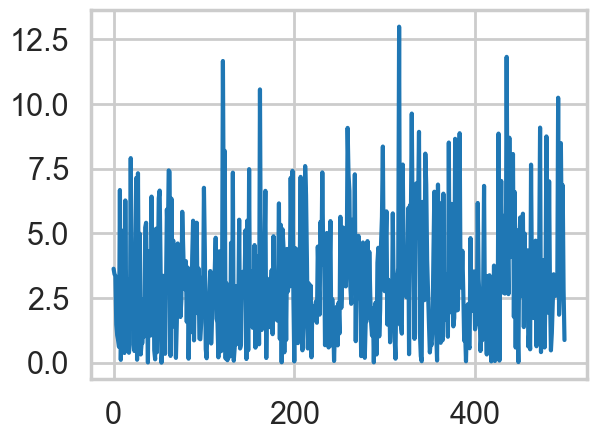

In [35]:
plt.plot(simu_lbdas)

In [36]:
choices = np.random.choice(simu_lbdas.shape[0], 100)
choices

array([287, 361, 192, 340, 446, 270, 154, 487, 101, 109, 191, 277, 312,
       128, 468, 356, 472, 111, 178, 428, 282, 487, 164,  88, 285,  90,
       180, 361,  87, 159, 495, 215, 432, 124,  85, 269, 210,  85, 162,
       184, 391, 177, 267, 330, 398, 214, 195,  88,  11, 130, 294,  26,
         2,  34, 358, 469,  65, 497, 311, 374, 279, 456, 305, 445,  35,
       264, 483,  54, 236, 222, 375, 499, 469, 448, 108, 339, 262, 272,
       440, 351, 239,  25, 181,  37, 333, 174, 499, 289, 128, 330,  47,
        36, 119, 270, 161, 222, 311, 312, 428, 443])

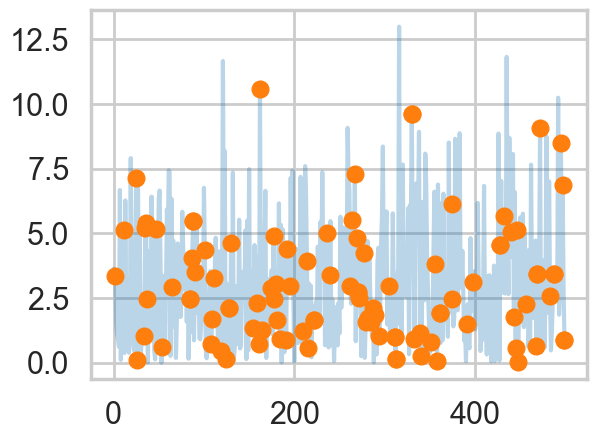

In [37]:
plt.plot(simu_lbdas, alpha=0.3)
plt.plot(choices, simu_lbdas[choices], 'o')

In [38]:
simlamsmall = simu_lbdas[choices]
simysmall = simy[choices,:]
simysmall.shape

(100, 365)

In [39]:
junkm = model_poisson1(4, y.shape[0], observed=simy[53,:])
with junkm:
    junkt = pm.sample(3000, tune=1000)

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [lambda]


/Users/rahul/Library/Caches/uv/archive-v0/WJgPh5nRFVZl0DU9tt8M7/lib/python3.14/site-packages/rich/live.py:260: 
UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 3_000 draw iterations (4_000 + 12_000 draws total) took 1 seconds.


There were 7 divergences after tuning. Increase `target_accept` or reparameterize.


In [40]:
simu_lbdas[53]

np.float64(0.0021002434617216218)

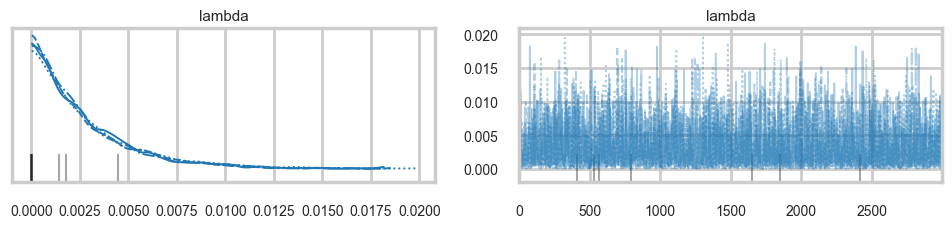

In [41]:
az.plot_trace(junkt);

In [42]:
az.summary(junkt)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
lambda,0.003,0.003,0.0,0.008,0.0,0.0,2549.0,2141.0,1.0


In [43]:
# Check convergence via rhat (replaces trace.report.ok)
summary = az.summary(junkt, var_names=['lambda'])
print("Rhat:", summary['r_hat'].values[0])
summary['r_hat'].values[0] < 1.05

Rhat: 1.0


np.True_

In [44]:
junkt.posterior['lambda'].values.flatten().shape

(12000,)

In [45]:
R=100
sbcpost = np.zeros((R, 12000))
problems = [False]*R
summaries = []
for i in range(R):
    m = model_poisson1(4, y.shape[0], observed=simysmall[i,:])
    idata_i = pm.sample(3000, tune=1000, model=m, progressbar=False)
    sbcpost[i,:] = idata_i.posterior['lambda'].values.flatten()
    s = az.summary(idata_i, var_names=['lambda'])
    summaries.append(s)
    problems[i] = s['r_hat'].values[0] < 1.05

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [lambda]


Sampling 4 chains for 1_000 tune and 3_000 draw iterations (4_000 + 12_000 draws total) took 1 seconds.


Initializing NUTS using jitter+adapt_diag...


...

Sampling 4 chains for 1_000 tune and 3_000 draw iterations (4_000 + 12_000 draws total) took 1 seconds.


Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [lambda]


Sampling 4 chains for 1_000 tune and 3_000 draw iterations (4_000 + 12_000 draws total) took 1 seconds.


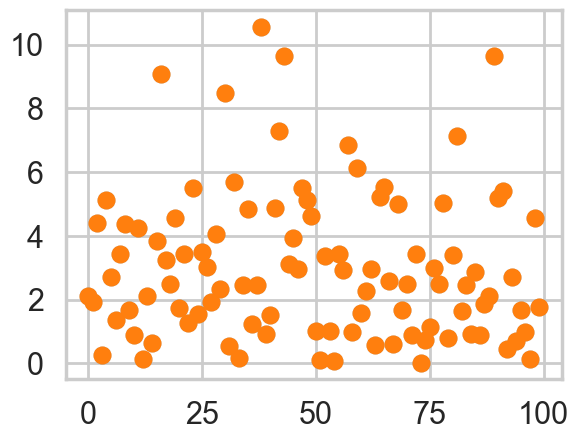

In [46]:
plt.plot(simlamsmall, 'o', alpha=0.3)
plt.plot(np.array(range(R))[problems], simlamsmall[problems], 'o')

### Calculating simulated posterior statistics

In [47]:
def sbc_rank(source_param, param_post, thin):
    return np.sum(source_param < param_post[::thin])
def z_scores_func(source_param, param_post):
    mean_param = np.mean(param_post)
    std_param = np.std(param_post)
    zs = np.abs(mean_param - source_param)/std_param
    return zs
def shrinkages_func(std_source, param_post):
    std_param = np.std(param_post)
    zs = 1. - (std_param*std_param)/(std_source*std_source)
    return zs    

In [48]:
summaries[0]

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
lambda,1.983,0.073,1.842,2.116,0.001,0.001,4935.0,7842.0,1.0


In [49]:
# posterior sensitivities analysis
z_scores = np.zeros(R)
shrinkages = np.zeros(R)
for i, s in enumerate(summaries):
    post_mean_lbda = s['mean'].values[0]
    #post_sd_lbda = s['sd'].values[0]
    prior_sd_lbda = 4.0
    print(simlamsmall[i], post_mean_lbda)
    #z_scores[i] = np.abs((post_mean_lbda - simlamsmall[i]) / post_sd_lbda)
    z_scores[i] = z_scores_func(simlamsmall[i], sbcpost[i,:])
    #shrinkages[i] = 1 - (post_sd_lbda / prior_sd_lbda ) ** 2
    shrinkages[i] = shrinkages_func(prior_sd_lbda, sbcpost[i,:])

2.111266928021367 1.983
1.932998647207024 2.005
4.400051915764061 4.512
0.2527554008030767 0.238
5.1262197837410985 5.171
2.7245080319061077 2.736
1.3493566679183466 1.369
3.420549707886031 3.619
4.373336304636476 4.307
1.6895953459078676 1.64
0.8808698194859278 0.848
4.235806382865925 4.241
0.15470488015424785 0.134
2.109229822971398 2.006
0.6360915248331712 0.6
3.833767891769012 3.802
9.089977661040377 9.305
3.256252479967535 3.243
2.4829502512323467 2.315
4.551847307898459 4.642
1.7265747049824254 1.654
3.420549707886031 3.618
1.2678621010024038 1.23
5.490247320817458 5.703
1.5618806139031076 1.539
3.4910230901679324 3.706
3.0380215615978 3.115
1.932998647207024 2.005
4.0521435151822045 4.202
2.320609664834795 2.32
8.491152658590035 8.314
0.5508625015978591 0.532
5.679441239307266 5.656
0.16082693753253818 0.16
2.447575286209122 2.447
4.837594414428688 4.884
1.2391008080123218 1.235
2.447575286209122 2.447
10.56607999785445 10.606
0.9218970600638887 0.811
1.5069532840097837 1.548
4.

### Shrinkage Plot

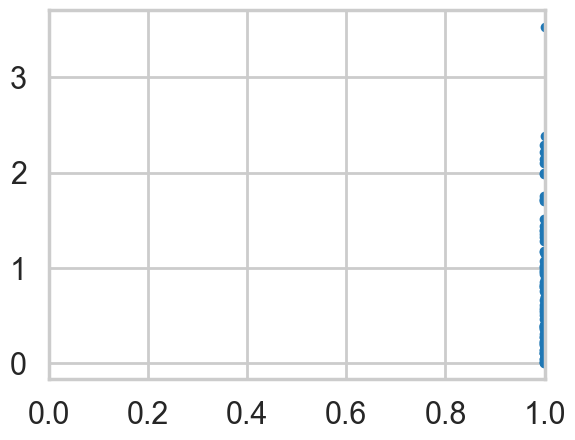

In [50]:
plt.plot(shrinkages, z_scores, '.');
plt.xlim([0,1]);

### Simulation Based Callibration

In [51]:
ranks=np.empty(R, dtype='int')
for i, lam in enumerate(simlamsmall):
    ranks[i] = sbc_rank(lam, sbcpost[i,:], 4)
ranks

array([ 110, 2492, 2534,  822, 1903, 1649, 1865, 2941,  811,  716,  739,
       1487,  431,  246,  555, 1131, 2708, 1326,   68, 2366,  451, 2928,
        774, 2879, 1084, 2959, 2373, 2501, 2747, 1502,  372,  890, 1261,
       1378, 1463, 1939, 1395, 1470, 1798,   42, 2162,  364, 2210, 1943,
       2043, 2172, 1209, 2882, 2967, 2873, 1217, 1236, 1183,  292,  875,
       2150,  208, 1337,  795, 2971,  520, 1250, 1437, 2443, 2315, 2484,
        416,  996, 1364, 1378,  464, 1282, 2058,   22,  369,  268,  537,
       2714, 1154, 1249, 2734,  632, 2264, 2151, 2198, 1036, 1363, 1967,
        262, 1928,  582, 1215, 1074, 1632, 2748, 1469,  872,  447, 2359,
        247])

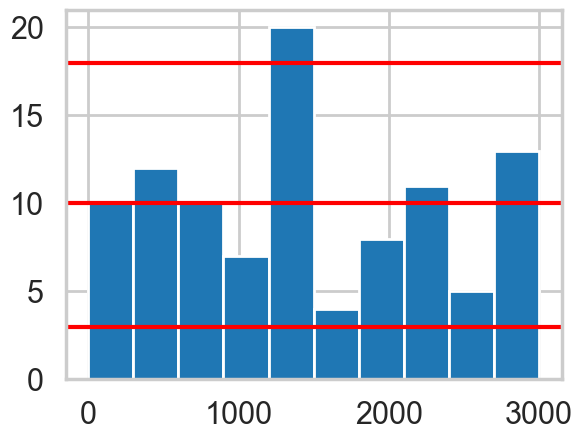

In [52]:
# 3000 left over samples after thinning by 4, 3001 spots, 100 replications
sbc_low = stats.binom.ppf(0.005, R, 300.0 / 3000)
sbc_mid = stats.binom.ppf(0.5, R, 300.0 / 3000)
sbc_high = stats.binom.ppf(0.995, R, 300.0 / 3000)
plt.hist(ranks, bins=[300*x for x in range(11)]);
plt.axhline(sbc_low, 0,1, c='r')
plt.axhline(sbc_mid, 0,1, c='r')
plt.axhline(sbc_high, 0,1, c='r')

### Posterior Predictive Check

In [53]:
mpo = model_poisson1(4, y.shape[0], observed=y)
with mpo:
    samples = pm.sample(3000, tune=1000)
posterior = samples.posterior['lambda'].values.flatten()

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [lambda]


/Users/rahul/Library/Caches/uv/archive-v0/WJgPh5nRFVZl0DU9tt8M7/lib/python3.14/site-packages/rich/live.py:260: 
UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 3_000 draw iterations (4_000 + 12_000 draws total) took 1 seconds.


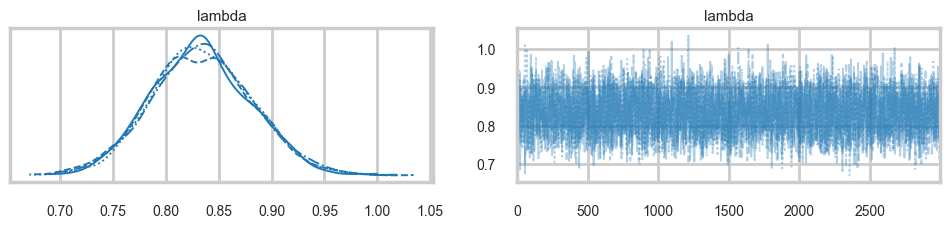

In [54]:
az.plot_trace(samples);

In [55]:
with mpo:
    samples_ppc = pm.sample_posterior_predictive(samples)

Sampling: [obsv]


/Users/rahul/Library/Caches/uv/archive-v0/WJgPh5nRFVZl0DU9tt8M7/lib/python3.14/site-packages/rich/live.py:260: 
UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

In [56]:
samples_ppc.posterior_predictive['obsv'].values.reshape(-1, N).shape

(12000, 365)

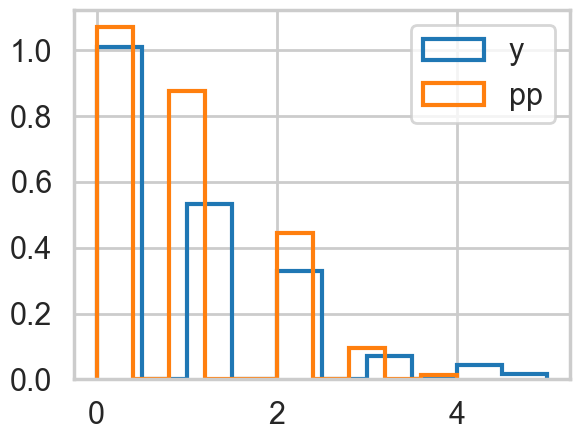

In [57]:
ppc_obsv = samples_ppc.posterior_predictive['obsv'].values.reshape(-1, N)
plt.hist(y,  density=True, histtype='step', lw=3, label="y");
plt.hist(ppc_obsv[0,:],  density=True, histtype='step', lw=3, label="pp")
plt.legend();

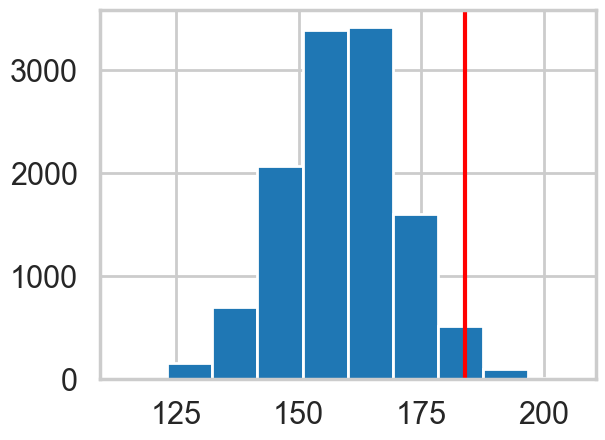

In [58]:
zeros = np.zeros(ppc_obsv.shape[0])
for i in range(ppc_obsv.shape[0]):
    zeros[i] = np.sum(ppc_obsv[i,:]==0)
plt.hist(zeros)
plt.axvline(np.sum(y==0), 0,1, c='r')

## A second model: 0 inflated poisson

The likelihood that combines the two cases considered above is called the **Zero Inflated poisson**. It has two arguments, the Poisson rate parameter, and the proportion of poisson variates (theta and psi in pymc).

In [59]:
def model_0ipoisson1(sd, shp, observed=None):
    with pm.Model() as model:
        lam=pm.HalfNormal("lambda", sigma=sd)
        theta=pm.Beta("theta", 1,1)
        like = pm.ZeroInflatedPoisson("obsv", mu=lam, psi=theta, shape = shp, observed=observed)
    return model

In [60]:
model2 = model_0ipoisson1(4, y.shape[0], observed=y)
with model2:
    trace2 = pm.sample(3000, tune=1000)

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [lambda, theta]


/Users/rahul/Library/Caches/uv/archive-v0/WJgPh5nRFVZl0DU9tt8M7/lib/python3.14/site-packages/rich/live.py:260: 
UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 3_000 draw iterations (4_000 + 12_000 draws total) took 2 seconds.


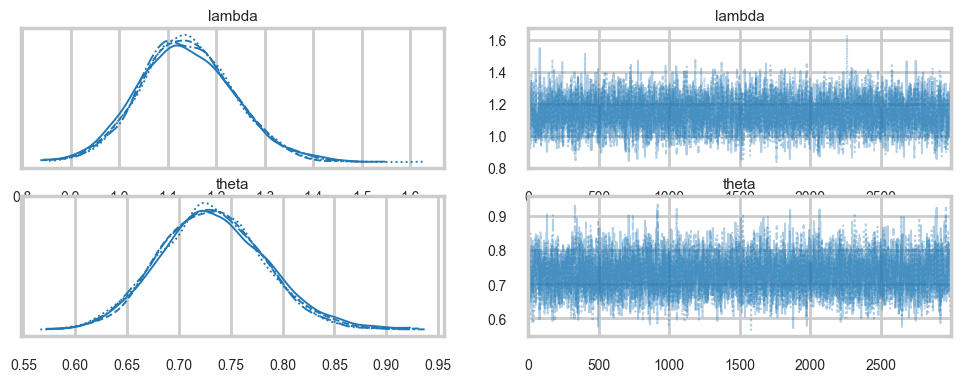

In [61]:
az.plot_trace(trace2);

In [62]:
az.summary(trace2)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
lambda,1.140,0.096,0.960,1.321,0.001,0.001,4169.0,4943.0,1.0
theta,0.732,0.051,0.639,0.830,0.001,0.001,4354.0,4905.0,1.0


### Identifiability Problems through simple prior-predictive checks

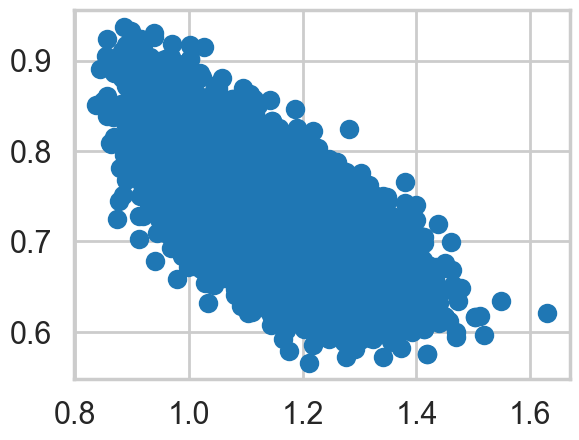

In [63]:
plt.scatter(trace2.posterior['lambda'].values.flatten(), trace2.posterior['theta'].values.flatten())

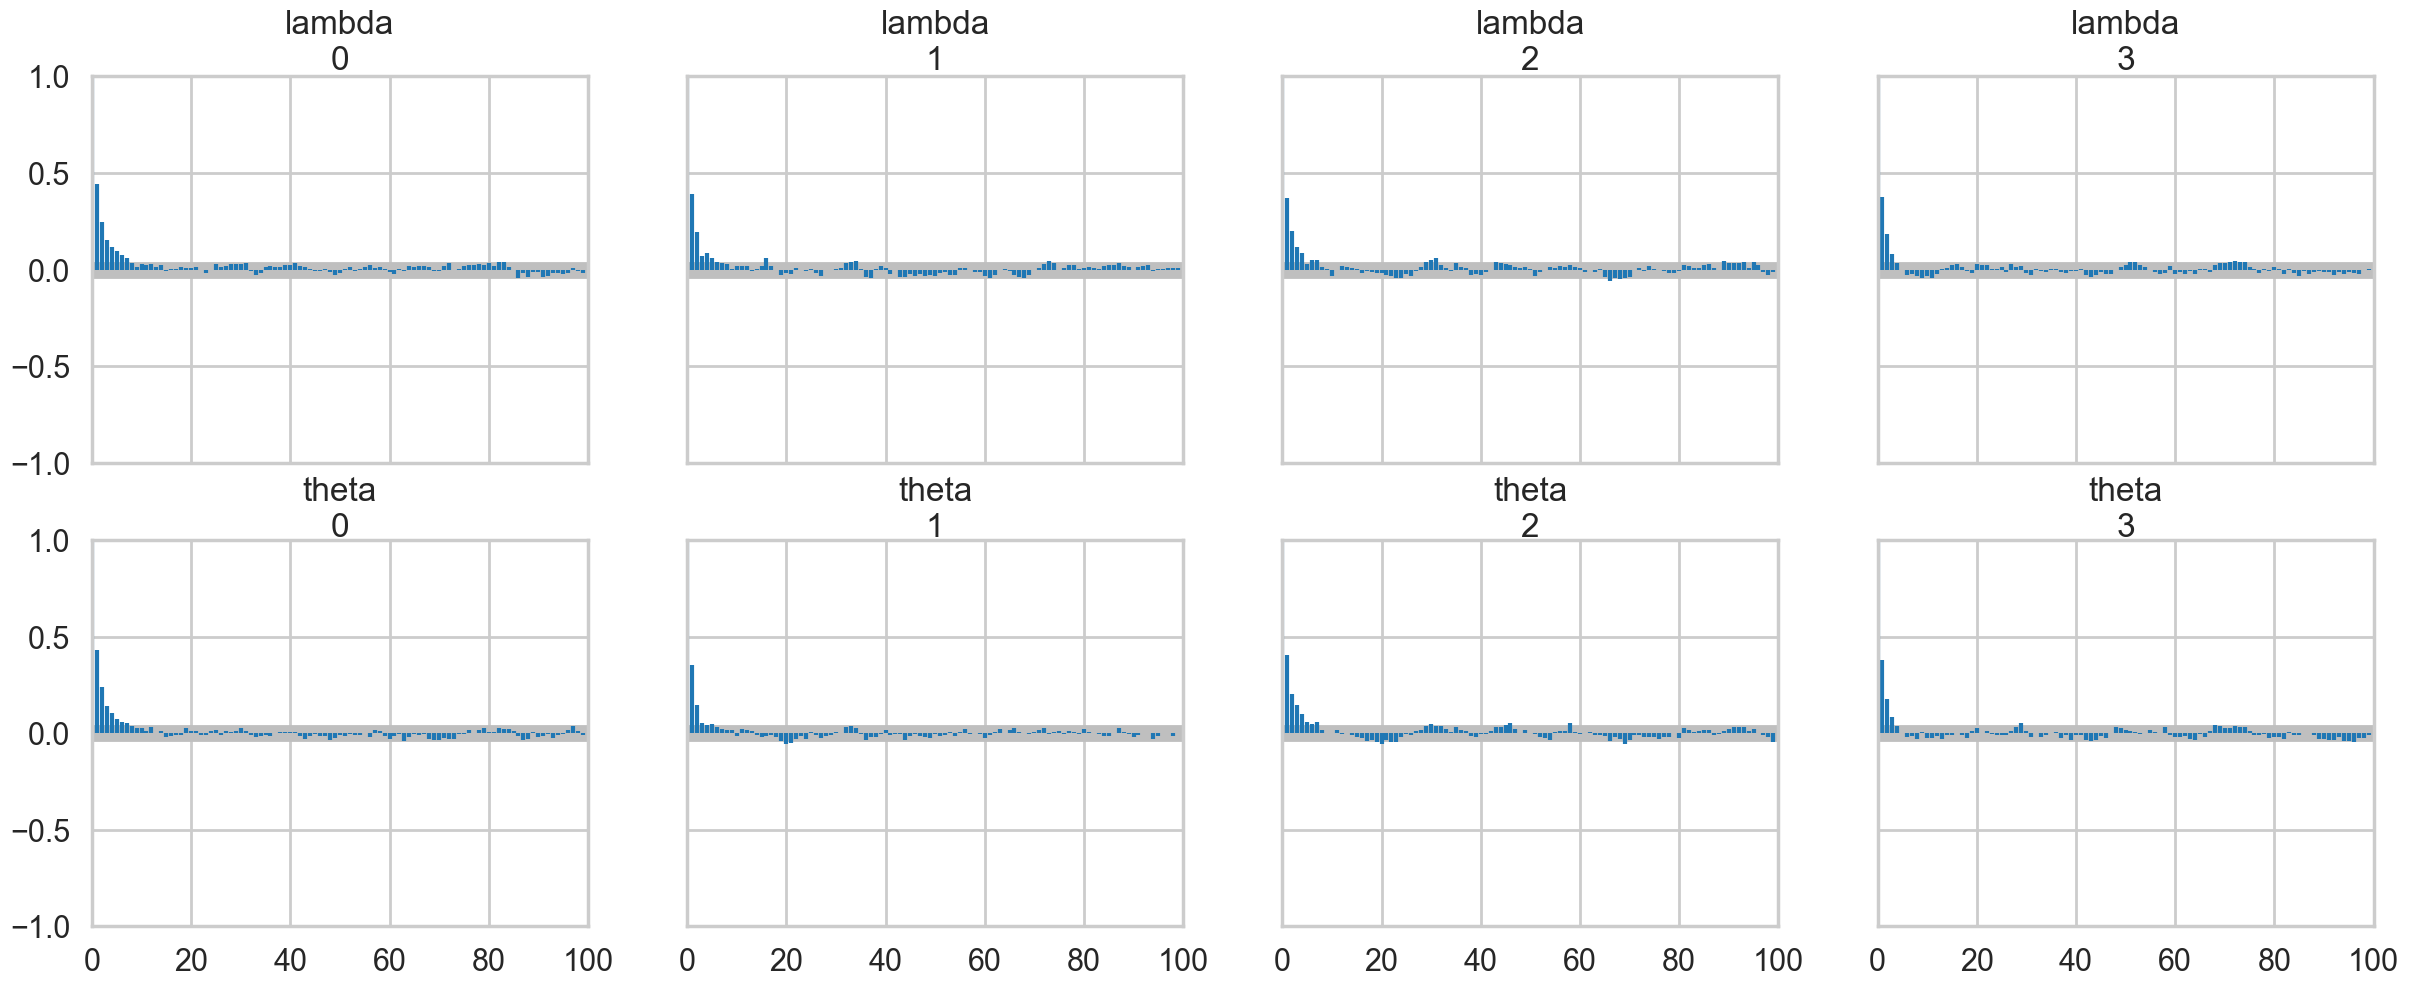

In [64]:
az.plot_autocorr(trace2);

### Sampling some prior predictives

We sample those likely to be troublesome, especially high drunkenness probability, and low productivity

In [65]:
simu_lbdas2 = stats.halfnorm(scale=4).rvs(500)
simu_betas2 = stats.beta(1,1).rvs(500)
simy2 = np.zeros((500, N))
for i in range(500):
    simu_bern = stats.bernoulli(1 - simu_betas2[i]).rvs(N).astype('bool')
    indices = np.array(range(N))[simu_bern]
    simy2[i,indices] = stats.poisson(simu_lbdas2[i]).rvs(indices.shape[0])

In [66]:
simy2[0,:].shape, simy2[53,:].shape

((365,), (365,))

In [67]:
lowlamindices = np.argsort(simu_lbdas2)[:5]
lowlamindices, simu_lbdas2[lowlamindices]

(array([ 40,  35, 306, 383,  61]),
 array([0.00476178, 0.06324101, 0.0638531 , 0.08554573, 0.08890198]))

In [68]:
highpindices = np.argsort(simu_betas2)[-5:]
highpindices, simu_betas2[highpindices]

(array([ 39, 109, 316, 304, 477]),
 array([0.99223398, 0.99377115, 0.99615021, 0.99720552, 0.99725129]))

In [69]:
reps_to_sample = np.concatenate((lowlamindices, highpindices))
reps_to_sample

array([ 40,  35, 306, 383,  61,  39, 109, 316, 304, 477])

In [70]:
reps_to_sample2 = np.concatenate((np.argsort(simu_lbdas2)[181:186], np.argsort(simu_betas2)[181:186]))

In [71]:
for j in reps_to_sample:
    m = model_0ipoisson1(4, N, observed=simy2[j,:])
    t = pm.sample(3000, tune=1000, model=m)

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [lambda, theta]


/Users/rahul/Library/Caches/uv/archive-v0/WJgPh5nRFVZl0DU9tt8M7/lib/python3.14/site-packages/rich/live.py:260: 
UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 3_000 draw iterations (4_000 + 12_000 draws total) took 2 seconds.


...

Multiprocess sampling (4 chains in 4 jobs)


NUTS: [lambda, theta]


/Users/rahul/Library/Caches/uv/archive-v0/WJgPh5nRFVZl0DU9tt8M7/lib/python3.14/site-packages/rich/live.py:260: 
UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 3_000 draw iterations (4_000 + 12_000 draws total) took 2 seconds.


There were 46 divergences after tuning. Increase `target_accept` or reparameterize.


In [72]:
for j in reps_to_sample2:
    m = model_0ipoisson1(4, N, observed=simy2[j,:])
    t = pm.sample(3000, tune=1000, model=m)

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [lambda, theta]


/Users/rahul/Library/Caches/uv/archive-v0/WJgPh5nRFVZl0DU9tt8M7/lib/python3.14/site-packages/rich/live.py:260: 
UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 3_000 draw iterations (4_000 + 12_000 draws total) took 1 seconds.


...

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [lambda, theta]


/Users/rahul/Library/Caches/uv/archive-v0/WJgPh5nRFVZl0DU9tt8M7/lib/python3.14/site-packages/rich/live.py:260: 
UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 3_000 draw iterations (4_000 + 12_000 draws total) took 2 seconds.


## In search of a better model

### Lets throw in some domain expertise

*A survey of Abbey Heads has told us, that the most a monk would produce, even at low productivity, one manuscript a day.*

### Choosing better Priors

In [73]:
cdfig = lambda alpha, beta: stats.invgamma(alpha,scale=beta).cdf(1)

In [74]:
asp = np.linspace(2,5,100)
bsp = np.linspace(7,10,100)
aa,bb = np.meshgrid(asp, bsp)
aa

array([[2.        , 2.03030303, 2.06060606, ..., 4.93939394, 4.96969697,
        5.        ],
       [2.        , 2.03030303, 2.06060606, ..., 4.93939394, 4.96969697,
        5.        ],
       [2.        , 2.03030303, 2.06060606, ..., 4.93939394, 4.96969697,
        5.        ],
       ...,
       [2.        , 2.03030303, 2.06060606, ..., 4.93939394, 4.96969697,
        5.        ],
       [2.        , 2.03030303, 2.06060606, ..., 4.93939394, 4.96969697,
        5.        ],
       [2.        , 2.03030303, 2.06060606, ..., 4.93939394, 4.96969697,
        5.        ]], shape=(100, 100))

In [75]:
z=cdfig(aa,bb)

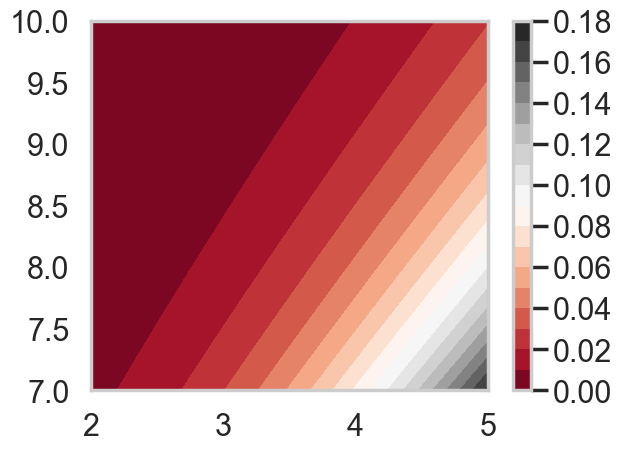

In [76]:
plt.contourf(aa, bb, z, 20, cmap='RdGy')
plt.colorbar();

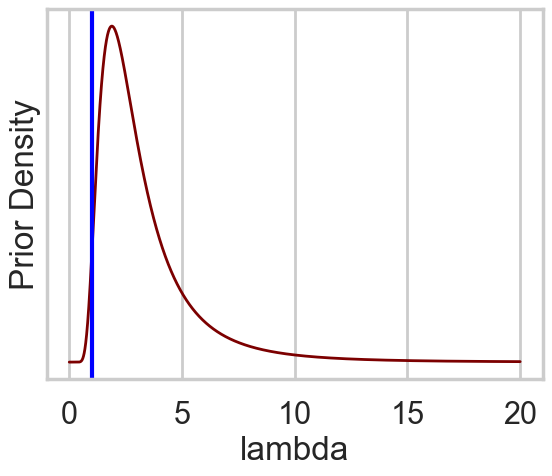

In [77]:
lbda  = np.linspace(0, 20, num=int(20/0.001))
alpha=3.5
beta=8.5
pdf = stats.invgamma(alpha, scale=beta)
plt.plot(lbda, pdf.pdf(lbda), c=c_dark_highlight, lw=2)
plt.xlabel("lambda"); plt.ylabel("Prior Density"); plt.yticks([]);
plt.axvline(1, 0, 1, c="blue")

In [78]:
stats.invgamma(alpha, scale=beta).cdf(1.), 1 - stats.invgamma(alpha, scale=beta).cdf(9.)

(np.float64(0.01739618256912451), np.float64(0.0342667918309546))

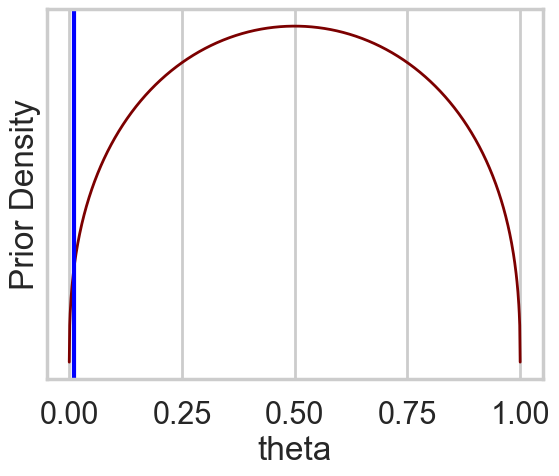

In [79]:
theta  = np.linspace(0, 1, num=int(1/0.001))
curve=1.4
pdf = stats.beta(curve, curve)
plt.plot(theta, pdf.pdf(theta), c=c_dark_highlight, lw=2)
plt.xlabel("theta"); plt.ylabel("Prior Density"); plt.yticks([]);
plt.axvline(0.01, 0, 1, c="blue")

In [80]:
stats.beta(curve, curve).cdf(0.2), 1 - stats.beta(curve, curve).cdf(0.8)

(np.float64(0.15200913356356724), np.float64(0.15200913356356716))

In [81]:
def model_0ipoisson2(alpha, beta, curve, shp, observed=None):
    with pm.Model() as model:
        lam = pm.InverseGamma("lambda",alpha=alpha,beta=beta)
        theta=pm.Beta("theta", curve, curve)
        like = pm.ZeroInflatedPoisson("obsv", mu=lam, psi=theta, shape = shp, observed=observed)
    return model

### Quick Posterior Predictive

We will in a later notebook, do the whole workflow, but in the meanwhile, here is the posterior predictive

In [82]:
model3 = model_0ipoisson2(alpha, beta, curve, y.shape[0], observed=y)
with model3:
    trace3 = pm.sample(3000, tune=1000)

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [lambda, theta]


/Users/rahul/Library/Caches/uv/archive-v0/WJgPh5nRFVZl0DU9tt8M7/lib/python3.14/site-packages/rich/live.py:260: 
UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 3_000 draw iterations (4_000 + 12_000 draws total) took 2 seconds.


In [83]:
az.summary(trace3)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
lambda,1.166,0.094,0.988,1.339,0.001,0.001,5082.0,5710.0,1.0
theta,0.721,0.049,0.629,0.814,0.001,0.000,4976.0,5159.0,1.0


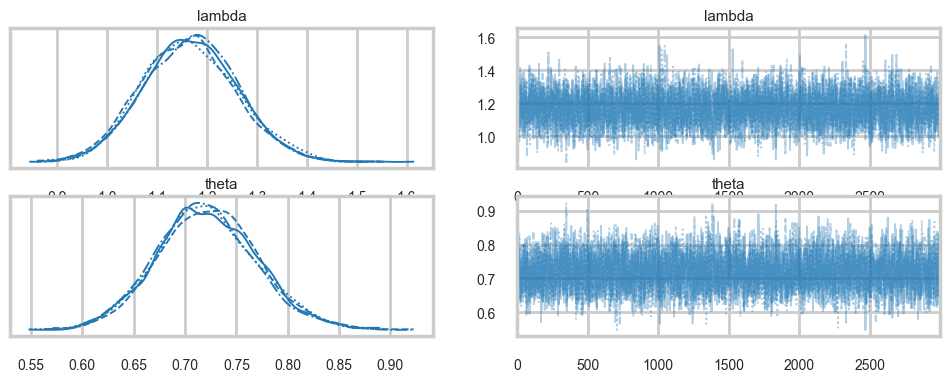

In [84]:
az.plot_trace(trace3);

### Sampling some prior predictives

Once again, we are looking at those likely to be troublesome...

In [85]:
simu_lbdas3 = stats.invgamma(alpha, scale=beta).rvs(500)
simu_betas3 = stats.beta(curve, curve).rvs(500)
simy3 = np.zeros((500, N))
for i in range(500):
    simu_bern = stats.bernoulli(1 - simu_betas3[i]).rvs(N).astype('bool')
    indices = np.array(range(N))[simu_bern]
    simy3[i,indices] = stats.poisson(simu_lbdas3[i]).rvs(indices.shape[0])

In [86]:
lowlamindices = np.argsort(simu_lbdas2)[:5]
lowlamindices, simu_lbdas2[lowlamindices]


(array([ 40,  35, 306, 383,  61]),
 array([0.00476178, 0.06324101, 0.0638531 , 0.08554573, 0.08890198]))

In [87]:
for j in lowlamindices:
    m = model_0ipoisson2(alpha, beta, curve, N, observed=simy2[j,:])
    t = pm.sample(3000, tune=1000, model=m)

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [lambda, theta]


/Users/rahul/Library/Caches/uv/archive-v0/WJgPh5nRFVZl0DU9tt8M7/lib/python3.14/site-packages/rich/live.py:260: 
UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 3_000 draw iterations (4_000 + 12_000 draws total) took 2 seconds.


...

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [lambda, theta]


/Users/rahul/Library/Caches/uv/archive-v0/WJgPh5nRFVZl0DU9tt8M7/lib/python3.14/site-packages/rich/live.py:260: 
UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 3_000 draw iterations (4_000 + 12_000 draws total) took 2 seconds.


In [88]:
highpindices = np.argsort(simu_betas2)[-5:]
highpindices, simu_betas2[highpindices]

(array([ 39, 109, 316, 304, 477]),
 array([0.99223398, 0.99377115, 0.99615021, 0.99720552, 0.99725129]))

In [89]:
for j in highpindices:
    m = model_0ipoisson2(alpha, beta, curve, N, observed=simy2[j,:])
    t = pm.sample(3000, tune=1000, model=m)

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [lambda, theta]


/Users/rahul/Library/Caches/uv/archive-v0/WJgPh5nRFVZl0DU9tt8M7/lib/python3.14/site-packages/rich/live.py:260: 
UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 3_000 draw iterations (4_000 + 12_000 draws total) took 1 seconds.


...

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [lambda, theta]


/Users/rahul/Library/Caches/uv/archive-v0/WJgPh5nRFVZl0DU9tt8M7/lib/python3.14/site-packages/rich/live.py:260: 
UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 3_000 draw iterations (4_000 + 12_000 draws total) took 1 seconds.
